## Data Preprocessing for Banking77

### Importing necessary libraries

In [1]:
from datasets import load_dataset

In [2]:
from __future__ import annotations

import io
from pathlib import Path

import pandas as pd
import urllib.request

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

### Login to Hugging Face Hub

In [4]:
from huggingface_hub import login

login()

### Loading dataset from github/huggingface

- load_data.py

In [5]:
from __future__ import annotations

import io
from pathlib import Path

import pandas as pd
import urllib.request

In [6]:
# Same URLs as the original loading script
_BASE = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data"
TRAIN_URL = f"{_BASE}/train.csv"
TEST_URL = f"{_BASE}/test.csv"

# Canonical label order copied verbatim from the original banking77.py
# (order matters: it defines the integer ids of the ClassLabel feature).
LABELS: list[str] = [
    "activate_my_card",
    "age_limit",
    "apple_pay_or_google_pay",
    "atm_support",
    "automatic_top_up",
    "balance_not_updated_after_bank_transfer",
    "balance_not_updated_after_cheque_or_cash_deposit",
    "beneficiary_not_allowed",
    "cancel_transfer",
    "card_about_to_expire",
    "card_acceptance",
    "card_arrival",
    "card_delivery_estimate",
    "card_linking",
    "card_not_working",
    "card_payment_fee_charged",
    "card_payment_not_recognised",
    "card_payment_wrong_exchange_rate",
    "card_swallowed",
    "cash_withdrawal_charge",
    "cash_withdrawal_not_recognised",
    "change_pin",
    "compromised_card",
    "contactless_not_working",
    "country_support",
    "declined_card_payment",
    "declined_cash_withdrawal",
    "declined_transfer",
    "direct_debit_payment_not_recognised",
    "disposable_card_limits",
    "edit_personal_details",
    "exchange_charge",
    "exchange_rate",
    "exchange_via_app",
    "extra_charge_on_statement",
    "failed_transfer",
    "fiat_currency_support",
    "get_disposable_virtual_card",
    "get_physical_card",
    "getting_spare_card",
    "getting_virtual_card",
    "lost_or_stolen_card",
    "lost_or_stolen_phone",
    "order_physical_card",
    "passcode_forgotten",
    "pending_card_payment",
    "pending_cash_withdrawal",
    "pending_top_up",
    "pending_transfer",
    "pin_blocked",
    "receiving_money",
    "Refund_not_showing_up",
    "request_refund",
    "reverted_card_payment?",
    "supported_cards_and_currencies",
    "terminate_account",
    "top_up_by_bank_transfer_charge",
    "top_up_by_card_charge",
    "top_up_by_cash_or_cheque",
    "top_up_failed",
    "top_up_limits",
    "top_up_reverted",
    "topping_up_by_card",
    "transaction_charged_twice",
    "transfer_fee_charged",
    "transfer_into_account",
    "transfer_not_received_by_recipient",
    "transfer_timing",
    "unable_to_verify_identity",
    "verify_my_identity",
    "verify_source_of_funds",
    "verify_top_up",
    "virtual_card_not_working",
    "visa_or_mastercard",
    "why_verify_identity",
    "wrong_amount_of_cash_received",
    "wrong_exchange_rate_for_cash_withdrawal",
]

label2id: dict[str, int] = {name: i for i, name in enumerate(LABELS)}
id2label: dict[int, str] = {i: name for i, name in enumerate(LABELS)}

In [7]:
def _read_csv(source: str, cache_dir: Path | None) -> pd.DataFrame:
    """Read a banking77 CSV from URL (with optional local caching) or path."""
    if source.startswith("http"):
        if cache_dir is not None:
            cache_dir.mkdir(parents=True, exist_ok=True)
            local = cache_dir / source.rsplit("/", 1)[-1]
            if not local.exists():
                urllib.request.urlretrieve(source, local)
            return pd.read_csv(local)
        with urllib.request.urlopen(source) as resp:
            return pd.read_csv(io.BytesIO(resp.read()))
    return pd.read_csv(source)

In [8]:
def load_banking77(
    cache_dir: str | Path | None = "data/raw",
    encode_labels: bool = True,
    validate: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load BANKING77 train/test as DataFrames with columns:
        text (str), category (str), and label (int, if encode_labels=True).

    cache_dir : local dir for caching the downloaded CSVs (None = no cache)
    """
    cache = Path(cache_dir) if cache_dir is not None else None
    train_df = _read_csv(TRAIN_URL, cache)
    test_df = _read_csv(TEST_URL, cache)

    for df in (train_df, test_df):
        df.columns = [c.strip() for c in df.columns]

    if encode_labels:
        for name, df in (("train", train_df), ("test", test_df)):
            unknown = set(df["category"]) - set(LABELS)
            if unknown:
                raise ValueError(f"Unknown categories in {name} split: {unknown}")
            df["label"] = df["category"].map(label2id.get).astype("int64")

    if validate:
        assert set(train_df["category"]) == set(LABELS), "train is missing some intents"
        assert set(test_df["category"]) <= set(LABELS)
        train_ok = bool(train_df["text"].notna().all())
        test_ok = bool(test_df["text"].notna().all())
        assert train_ok and test_ok

    return train_df, test_df

### Inspecting the datasets

In [9]:
train, test = load_banking77()
print(f"train: {len(train):,} rows | test: {len(test):,} rows | intents: {train['category'].nunique()}")

train: 10,003 rows | test: 3,080 rows | intents: 77


In [10]:
train.head()

,text,category,label
0,I am still waiting on my card?,card_arrival,11
1,What can I do if my card still hasn't arrived ...,card_arrival,11
2,I have been waiting over a week. Is the card s...,card_arrival,11
3,Can I track my card while it is in the process...,card_arrival,11
4,"How do I know if I will get my card, or if it ...",card_arrival,11


In [11]:
test.head()

,text,category,label
0,How do I locate my card?,card_arrival,11
1,"I still have not received my new card, I order...",card_arrival,11
2,I ordered a card but it has not arrived. Help ...,card_arrival,11
3,Is there a way to know when my card will arrive?,card_arrival,11
4,My card has not arrived yet.,card_arrival,11


## Preprocess Data

In [12]:
from __future__ import annotations

import argparse
import json
import re
from pathlib import Path
from typing import Literal, TypedDict, cast

import pandas as pd
from sklearn.model_selection import train_test_split

In [13]:
_WS = re.compile(r"\s+")


class Banking77Splits(TypedDict):
    train: pd.DataFrame
    validation: pd.DataFrame
    test: pd.DataFrame


def clean_text(s: pd.Series) -> pd.Series:
    """Minimal, safe cleaning: strip + collapse internal whitespace.

    Deliberately does NOT lowercase or strip punctuation: subword tokenizers
    handle both, and question marks / phrasing are useful intent signals.
    """

    def _collapse_ws(text: str) -> str:
        return _WS.sub(" ", text)

    return s.astype(str).str.strip().map(_collapse_ws)

In [14]:
def deduplicate(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    before = len(df)
    deduped = df.drop_duplicates(subset=["text", "label"], keep="first").reset_index(drop=True)
    return deduped, before - len(deduped)

In [15]:
def make_validation_split(
    train_df: pd.DataFrame, val_size: float, seed: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    tr, va = cast(
        tuple[pd.DataFrame, pd.DataFrame],
        train_test_split(
            train_df,
            test_size=val_size,
            random_state=seed,
            stratify=train_df["label"],
        ),
    )
    return tr.reset_index(drop=True), va.reset_index(drop=True)

In [16]:
def preprocess(
    val_size: float = 0.1,
    seed: int = 42,
    out_dir: str | Path | None = "data/processed",
    dedupe: bool = True,
) -> Banking77Splits:
    """Full pipeline. Returns train, validation, and test DataFrames."""
    train_df, test_df = load_banking77()

    for df in (train_df, test_df):
        text_col = cast(pd.Series, df["text"])
        df["text"] = clean_text(text_col)

    if dedupe:
        train_df, removed = deduplicate(train_df)
        print(f"deduplicated train: removed {removed} exact (text,label) duplicates")

    tr, va = make_validation_split(train_df, val_size, seed)

    splits: Banking77Splits = {"train": tr, "validation": va, "test": test_df}
    split_names: tuple[Literal["train", "validation", "test"], ...] = (
        "train",
        "validation",
        "test",
    )
    for name in split_names:
        df = splits[name]
        counts = df["label"].value_counts()
        print(
            f"{name:>10}: {len(df):>6,} rows | {df['label'].nunique()} intents | "
            f"min/class={counts.min()}, max/class={counts.max()}"
        )

    # sanity: every intent present in every split
    for name in split_names:
        df = splits[name]
        missing = set(range(len(LABELS))) - set(df["label"].unique())
        if missing:
            raise RuntimeError(
                f"{name} split is missing intents: {sorted(missing)} "
                f"- lower val_size or reduce dedupe"
            )

    if out_dir is not None:
        out = Path(out_dir)
        out.mkdir(parents=True, exist_ok=True)
        try:
            for name in split_names:
                df = splits[name]
                df[["text", "category", "label"]].to_parquet(out / f"{name}.parquet", index=False)
        except ImportError:
            print(
                "pyarrow/fastparquet not installed - saving CSV instead "
                "(pip install pyarrow for parquet)"
            )
            for name in split_names:
                df = splits[name]
                df[["text", "category", "label"]].to_csv(out / f"{name}.csv", index=False)
        (out / "label_mapping.json").write_text(
            json.dumps({"label2id": label2id, "id2label": id2label}, indent=2)
        )
        print(f"wrote parquet splits + label_mapping.json to: {out.resolve()}")

    return splits

## Analyzing the data

In [17]:
from __future__ import annotations

import argparse
from pathlib import Path
from typing import cast

import matplotlib

matplotlib.use("Agg")  # safe default for scripts; notebooks can override
import matplotlib.pyplot as plt
import pandas as pd

# import load_banking77

In [18]:
def per_class_stats(train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    """Per-intent counts and text-length stats (words), train vs test."""

    def agg(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
        g = df.assign(n_words=df["text"].str.split().str.len()).groupby("category")
        return cast(
            pd.DataFrame,
            g.agg(
                **{
                    f"{prefix}_count": ("text", "size"),
                    f"{prefix}_avg_words": ("n_words", "mean"),
                    f"{prefix}_max_words": ("n_words", "max"),
                }
            ),
        )

    stats = agg(train_df, "train").join(agg(test_df, "test"), how="outer")
    stats["train_share_%"] = 100 * stats["train_count"] / stats["train_count"].sum()
    return stats.sort_values("train_count", ascending=False).round(2)

In [19]:
def quality_checks(train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict[str, int]:
    """Duplicates, empty texts, and train/test leakage."""
    train_texts = train_df["text"].str.strip().str.lower()
    test_texts = test_df["text"].str.strip().str.lower()

    dup_train = int(train_texts.duplicated().sum())
    dup_test = int(test_texts.duplicated().sum())
    leakage = int(test_texts.isin(set(train_texts)).sum())

    # same text labeled with different intents (annotation conflicts)
    conflicts = train_df.assign(t=train_texts).groupby("t")["category"].nunique()
    conflict_count = int((conflicts > 1).sum())

    return {
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "n_intents_train": cast(int, train_df["category"].nunique(dropna=False)),
        "n_intents_test": cast(int, test_df["category"].nunique(dropna=False)),
        "duplicate_texts_train": dup_train,
        "duplicate_texts_test": dup_test,
        "train_test_overlap_texts": leakage,
        "label_conflicts_train": conflict_count,
        "empty_texts_train": int((train_texts.str.len() == 0).sum()),
        "empty_texts_test": int((test_texts.str.len() == 0).sum()),
    }

In [20]:
def plot_class_distribution(train_df: pd.DataFrame, out: Path) -> None:
    counts = train_df["category"].value_counts()
    fig, ax = plt.subplots(figsize=(10, 16))
    counts.sort_values().plot.barh(ax=ax, color="#4C72B0")
    ax.set_title("BANKING77 - train examples per intent")
    ax.set_xlabel("count")
    ax.tick_params(axis="y", labelsize=7)
    fig.tight_layout()
    fig.savefig(out / "class_distribution.png", dpi=150)
    plt.close(fig)

In [21]:
def plot_text_lengths(train_df: pd.DataFrame, test_df: pd.DataFrame, out: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    splits: list[tuple[str, pd.DataFrame]] = [("train", train_df), ("test", test_df)]
    for ax, (name, df) in zip(axes, splits, strict=True):
        lengths = df["text"].str.split().str.len()
        ax.hist(lengths, bins=40, color="#55A868")
        ax.set_title(
            f"{name}: words per query (p95={lengths.quantile(0.95):.0f}, max={lengths.max()})"
        )
        ax.set_xlabel("words")
    fig.tight_layout()
    fig.savefig(out / "text_length_distribution.png", dpi=150)
    plt.close(fig)

In [22]:
def plot_length_by_class(train_df: pd.DataFrame, out: Path, top_n: int = 20) -> None:
    lengths = train_df.assign(n_words=train_df["text"].str.split().str.len())
    means = cast(pd.Series, lengths.groupby("category")["n_words"].mean())
    top = means.sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    top.sort_values(ascending=True).plot.barh(ax=ax, color="#C44E52")
    ax.set_title(f"Top {top_n} intents by average query length (train)")
    ax.set_xlabel("avg words")
    fig.tight_layout()
    fig.savefig(out / "tokens_per_class.png", dpi=150)
    plt.close(fig)

In [23]:
def run_eda(
    train_df: pd.DataFrame | None = None,
    test_df: pd.DataFrame | None = None,
    out_dir: str | Path = "reports/eda",
    show: bool = False,
) -> pd.DataFrame:
    """Run full EDA. Returns the per-intent stats table."""
    if train_df is None or test_df is None:
        loaded_train, loaded_test = load_banking77()
        if train_df is None:
            train_df = loaded_train
        if test_df is None:
            test_df = loaded_test

    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    checks = quality_checks(train_df, test_df)
    print("=== Data quality / shape ===")
    for k, v in checks.items():
        print(f"  {k:>28}: {v:,}")

    stats = per_class_stats(train_df, test_df)
    stats.to_csv(out / "eda_summary.csv")

    imbalance = stats["train_count"].max() / stats["train_count"].min()
    print("\n=== Class balance (train) ===")
    print(f"  largest intent : {stats['train_count'].idxmax()} ({stats['train_count'].max():.0f})")
    print(f"  smallest intent: {stats['train_count'].idxmin()} ({stats['train_count'].min():.0f})")
    print(f"  imbalance ratio: {imbalance:.1f}x")

    lengths = train_df["text"].str.split().str.len()
    print("\n=== Text length (train, words) ===")
    print(
        f"  mean={lengths.mean():.1f}  median={lengths.median():.0f}  "
        f"p95={lengths.quantile(0.95):.0f}  max={lengths.max()}"
    )
    print("  -> use p95/max to pick tokenizer max_length for fine-tuning")

    plot_class_distribution(train_df, out)
    plot_text_lengths(train_df, test_df, out)
    plot_length_by_class(train_df, out)
    print(f"\nPlots + eda_summary.csv written to: {out.resolve()}")

    if show:  # in a notebook, also display inline
        try:
            from IPython.display import Image, display
        except ImportError:
            for img in [
                "class_distribution.png",
                "text_length_distribution.png",
                "tokens_per_class.png",
            ]:
                print(f"(open {out / img})")
        else:
            for img in [
                "class_distribution.png",
                "text_length_distribution.png",
                "tokens_per_class.png",
            ]:
                display(Image(filename=str(out / img)))

    return stats

deduplicated train: removed 4 exact (text,label) duplicates
     train:  8,999 rows | 77 intents | min/class=32, max/class=168
validation:  1,000 rows | 77 intents | min/class=3, max/class=19
      test:  3,080 rows | 77 intents | min/class=40, max/class=40
wrote parquet splits + label_mapping.json to: /Users/sudhanshu/Documents/gitrepository/llm-finetuning/llm-ft-for-classification/notebooks/data/processed
=== Data quality / shape ===
                    train_rows: 10,003
                     test_rows: 3,080
               n_intents_train: 77
                n_intents_test: 77
         duplicate_texts_train: 4
          duplicate_texts_test: 1
      train_test_overlap_texts: 6
         label_conflicts_train: 0
             empty_texts_train: 0
              empty_texts_test: 0

=== Class balance (train) ===
  largest intent : card_payment_fee_charged (187)
  smallest intent: contactless_not_working (35)
  imbalance ratio: 5.3x

=== Text length (train, words) ===
  mean=11.9  median=

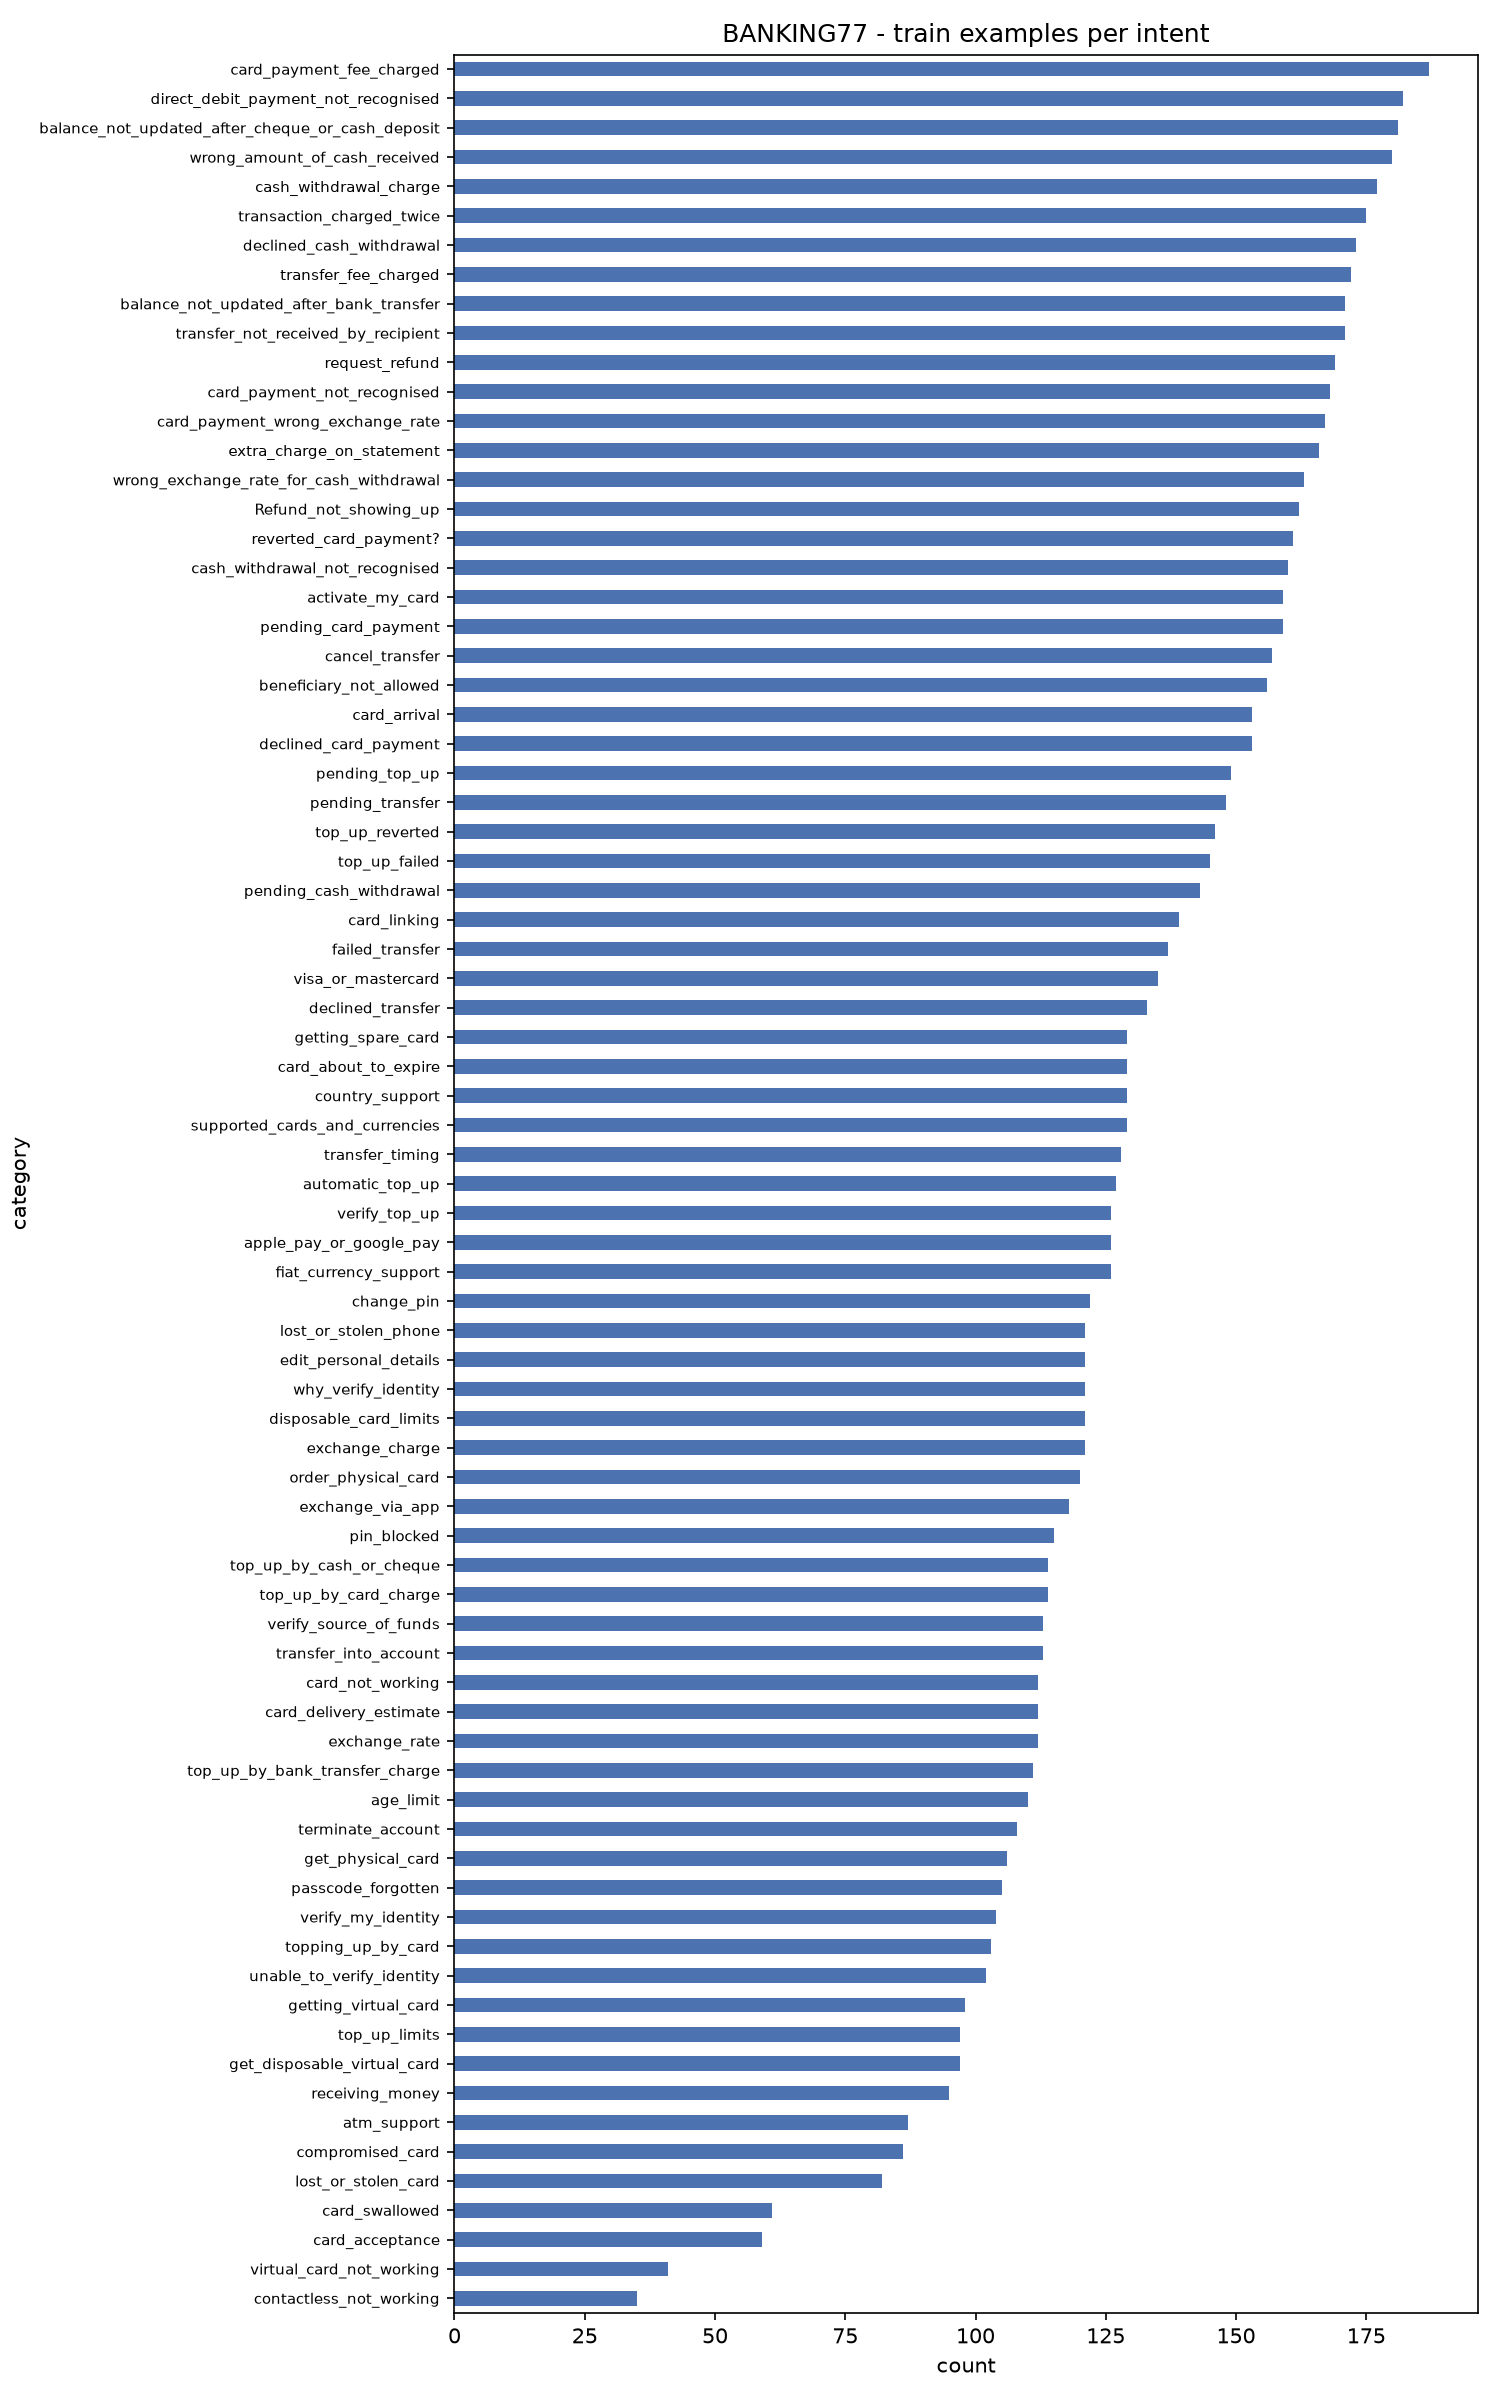

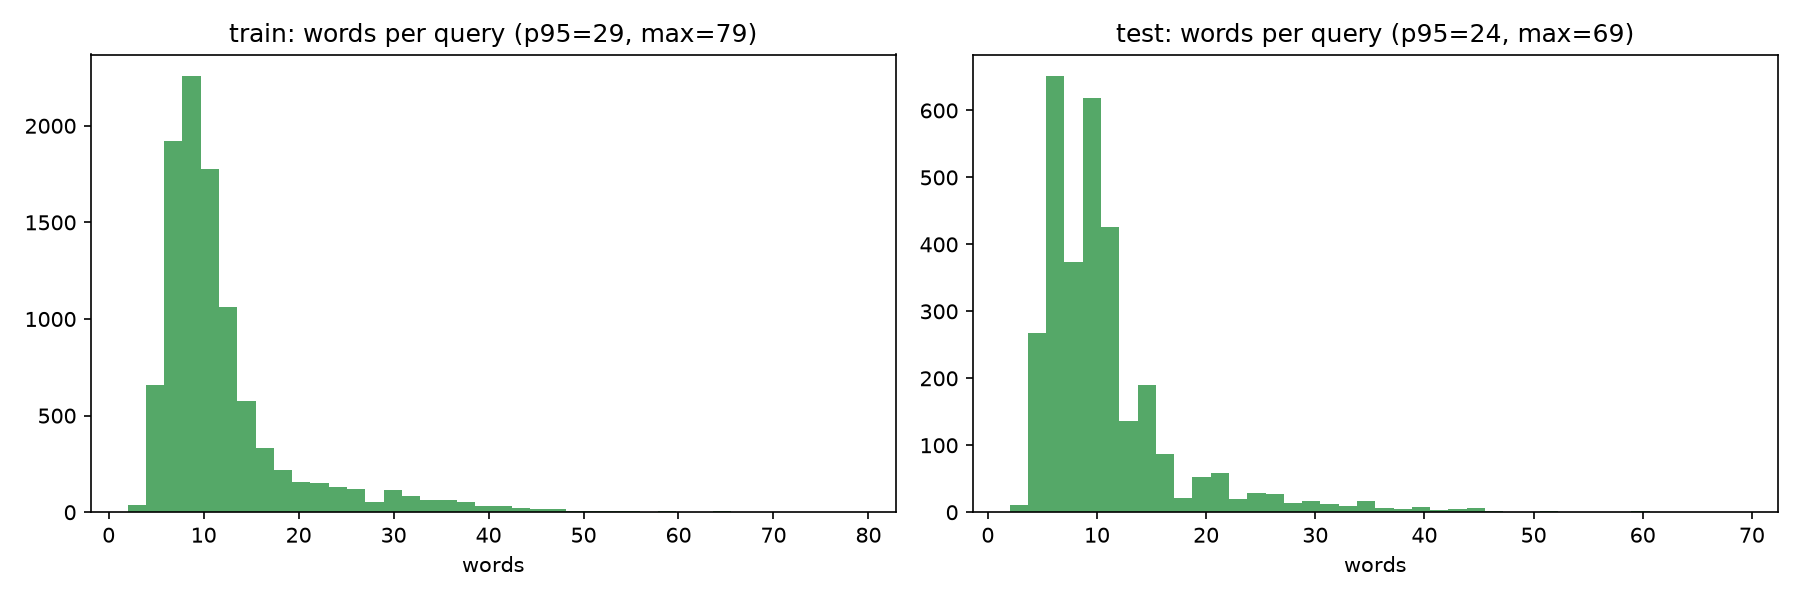

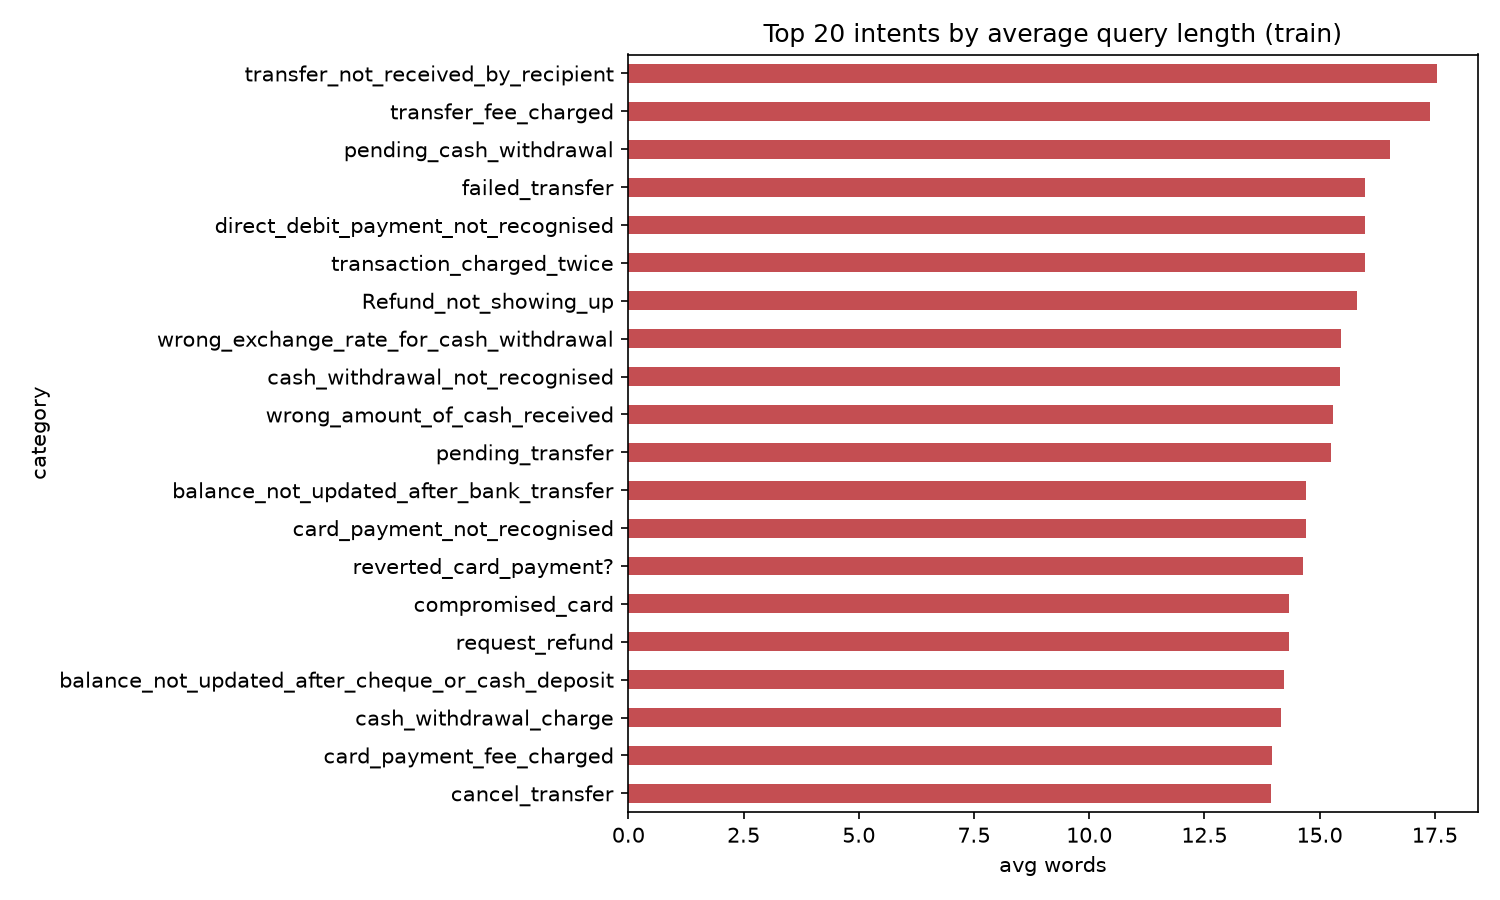

In [24]:
# Loading the dataset from source
train_df, test_df = load_banking77()

# Splitting the dataset 
splits = preprocess(val_size=0.1, out_dir="data/processed")

# extracting data for analysis
stats = run_eda(train_df, test_df, show=True)